### Import dependencies

In [92]:
# Import dependencies
import openai
import instructor
from pydantic import BaseModel, Field
import os
import json
import pandas as pd
from typing import Any,Annotated,List,Literal,Optional, Sequence
from superlinked import framework as sl
from api.agents.superlinked_app.index import business_index, business
from api.agents.superlinked_app.query import query
from api.agents.superlinked_app.utils.utils import *
from typing import List
from jinja2 import Template
from openai import OpenAI
from operator import add
from langsmith import traceable, get_current_run_tree
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langgraph.types import Send, Command


In [65]:
qdrant_vdb = sl.QdrantVectorDatabase(
    url="http://localhost:6333",
    # Superlinked's QdrantVectorDatabase currently requires an api_key arg.
    # For local Qdrant this is typically unused, so we default to empty.
    api_key=os.getenv("QDRANT_API_KEY", ""),
)
parser = sl.DataFrameParser(business)

source_qdrant = sl.RestSource(
    business,
    parser=parser,
)

# RestExecutor needs sl.RestQuery (path for /api/v1/search/<query_path> by default).
business_rest_query = sl.RestQuery(
    rest_descriptor=sl.RestDescriptor(query_path="business_search"),
    query_descriptor=query,
)

executor_qdrant = sl.RestExecutor(
    sources=[source_qdrant],
    indices=[business_index],
    vector_database=qdrant_vdb,
    queries=[business_rest_query],
)
qdrant_app = executor_qdrant.run()


def Retrieve_context(question, qdrant_app, k=5):
    qdrant_results = qdrant_app.query(
        query,
        natural_query=question,
        limit=k,
    )

    format_minute_columns_to_hhmm(sl.PandasConverter.to_pandas(qdrant_results))

    return {
        "retrived_restaurant_ids":[e.id for e in qdrant_results.entries],
        "retrived_restaurants_names":[e.fields.get("name") for e in qdrant_results.entries],
        "retrived_restaurants_ratings":[e.fields.get("stars") for e in qdrant_results.entries],
        "retrived_restaurants_reviews_count":[e.fields.get("review_count") for e in qdrant_results.entries],
        "retrived_states":[e.fields.get("state") for e in qdrant_results.entries],
        "retrived_cities":[e.fields.get("city") for e in qdrant_results.entries],
        "similarity_scores":[e.metadata.score for e in qdrant_results.entries],
    }


    

/Users/wilfriedtcheumaha/Code/yelp-assistant/.venv/lib/python3.12/site-packages/superlinked/framework/storage/qdrant/qdrant_vdb_connector.py:87: UserWarning: Api key is used with an insecure connection.
  self._client = AsyncQdrantClient(
/Users/wilfriedtcheumaha/Code/yelp-assistant/.venv/lib/python3.12/site-packages/superlinked/framework/storage/qdrant/qdrant_vdb_connector.py:92: UserWarning: Api key is used with an insecure connection.
  self._sync_client = QdrantClient(


20:40:53 superlinked.framework.query.query_dag_evaluator INFO   initialized query dag
20:40:53 superlinked.framework.online.online_dag_evaluator INFO   initialized entity dag


In [66]:
user_question = "4 popular restaurants in tampa"

In [67]:
Retrieve_context(user_question, qdrant_app)

20:41:01 superlinked.framework.common.delayed_evaluator INFO   Processed sentence-transformers/all-MiniLM-L6-v2 embed
20:41:01 superlinked.framework.query.query_dag_evaluator INFO   evaluated query
20:41:01 superlinked.framework.dsl.executor.query.query_executor INFO   executed query


{'retrived_restaurant_ids': ['YbEVMCXzbcibj2a11Yzg1g',
  'yui1n1JawiW9g7RR62a_wA',
  'n_7EQxn0ciucIOJfpWVaTQ',
  'cd-rz-piYMftZtbFU82x8g',
  'UWB_Oi9dkPwXfhYgFMnjsw'],
 'retrived_restaurants_names': ['Shells Seafood Restaurant - South Tampa',
  'Matoi Sushi',
  'Saigon Deli',
  "Mr. Dunderbak's",
  "Pinky's"],
 'retrived_restaurants_ratings': [4.5, 4.0, 4.5, 4.5, 4.0],
 'retrived_restaurants_reviews_count': [453, 594, 738, 825, 625],
 'retrived_states': ['FL', 'FL', 'FL', 'FL', 'FL'],
 'retrived_cities': ['Tampa', 'Tampa', 'Tampa', 'Tampa', 'Tampa'],
 'similarity_scores': [0.8642123,
  0.82326317,
  0.82087743,
  0.81966984,
  0.8142859]}

### Multi-Intent queries

In [68]:
df=pd.read_json("../data/raw/yelp_academic_dataset_business_restaurants_with_hours_sample_1000.json",lines=True)

In [69]:
df.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,cHZ1FUswyko119EkV_9aNQ,Upper Crust Pizza,1909 E Grant Rd,Tucson,AZ,85719,32.250429,-110.943524,3.5,180,1,"{'BikeParking': 'True', 'RestaurantsPriceRange...","Salad, Pizza, Chicken Wings, Restaurants","{'Monday': '11:0-21:0', 'Tuesday': '11:0-21:0'..."
1,goTAL_3Ns-bsMgfGmKDq0A,Spitale's Deli & Catering,3309 Division St,Metairie,LA,70002,30.004793,-90.164386,4.5,53,1,"{'RestaurantsPriceRange2': '1', 'RestaurantsRe...","American (New), Restaurants, Local Flavor, Delis","{'Monday': '9:0-16:0', 'Tuesday': '10:30-20:0'..."
2,L1TzHZ8OXfVXTfyzidstzg,Snooze An AM Eatery,"2500 E Grant Rd, Ste 182",Tucson,AZ,85716,32.250337,-110.935414,4.5,253,1,"{'Caters': 'True', 'OutdoorSeating': 'True', '...","Breakfast & Brunch, American (Traditional), Sa...","{'Monday': '0:0-0:0', 'Tuesday': '6:30-14:30',..."
3,DfkO7MHuy2wxgeUZ2-o3BA,Subway,204 St Charles Ave,New Orleans,LA,70130,29.951985,-90.069679,3.0,8,0,"{'RestaurantsTakeOut': 'True', 'RestaurantsDel...","Restaurants, Sandwiches, Fast Food","{'Monday': '7:0-17:0', 'Tuesday': '7:0-17:0', ..."
4,ByKCIpZWHYUTuCJcoZ-ONQ,Giovanni's,6583 Pardall Rd,Goleta,CA,93117,34.412901,-119.857810,4.0,87,0,"{'RestaurantsTakeOut': 'True', 'RestaurantsGoo...","Salad, Sandwiches, Restaurants, Pizza, Italian","{'Monday': '11:0-20:0', 'Tuesday': '11:0-20:0'..."


In [70]:
question = "3 popular restaurants in tucson and 2 best restaurants in New Orleans"

In [71]:
Retrieve_context(question, qdrant_app)

20:41:07 superlinked.framework.query.query_dag_evaluator INFO   evaluated query
20:41:07 superlinked.framework.dsl.executor.query.query_executor INFO   executed query


{'retrived_restaurant_ids': ['ZHcfV3d7ZW8bmwgKCsz-RA',
  'tV46IhCfHbsx_af-pMupiw',
  'IKMAgK2m6WRIViVFB2vAFQ',
  'L1TzHZ8OXfVXTfyzidstzg',
  '4jkH3istYst8zxLxb-QVmg'],
 'retrived_restaurants_names': ['Pizza Luna',
  'Cafe Poca Cosa',
  'Miss Saigon',
  'Snooze An AM Eatery',
  'La Parrilla Suiza'],
 'retrived_restaurants_ratings': [4.5, 4.0, 4.0, 4.5, 3.0],
 'retrived_restaurants_reviews_count': [251, 1306, 702, 253, 340],
 'retrived_states': ['AZ', 'AZ', 'AZ', 'AZ', 'AZ'],
 'retrived_cities': ['Tucson', 'Tucson', 'Tucson', 'Tucson', 'Tucson'],
 'similarity_scores': [0.82659674,
  0.8255422,
  0.79330504,
  0.78300595,
  0.78156775]}

In [72]:
class QueryExpandResponse(BaseModel):
   statements: List[str]

In [73]:
def query_expand_node(query) -> dict:

   prompt_template =  """You are part of a shopping assistant that can answer questions about products in stock.

Instructions:
- You will be given a question and you need to expand it into a list of statements that can be used in contextual search to retrieve relevant products.
- The statements should not overlap in context.

<Question>
{{ query }}
</Question>
"""

   template = Template(prompt_template)
   
   prompt = template.render(
      query=query
   )

   client = instructor.from_openai(OpenAI())

   response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=QueryExpandResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
   )

   return {
      "queries": response.statements
   }

In [74]:
answer = query_expand_node(question)

In [75]:
answer

{'queries': ['popular restaurants in Tucson',
  'best restaurants in New Orleans',
  'top rated restaurants in Tucson',
  'highly recommended restaurants in New Orleans',
  'well known dining places in Tucson',
  'famous restaurants in New Orleans']}

### Langraph

#### Quer expansion (Sequential execution)

In [76]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[dict], add] = []
    initial_query: str = ""
    answer: str = ""

#### Query expansion/Rewriting Node

In [77]:
class QueryExpandResponse(BaseModel):
   expanded_query: List[str]

In [78]:
@traceable(
   name="query_expand_node",
   run_type="llm",
   metadata={"ls_provider":"openai", "ls_model_name":"gpt-4.1-mini"}
   )
def query_expand_node(state:State) -> dict:

   prompt_template =  """ou are part of a shopping assistant that can answer questions about restaurants.

Instructions:
- You will be given a question and you need to expand it into a list of statements that can be used in contextual search to retrieve relevant products.
- The statements should not overlap in context.
- Be as concise as possible, do not make up synonims for statements, one statement per piece of context.

<Question>
{{ query }}
</Question>
"""

   template = Template(prompt_template)
   
   prompt = template.render(
      query=state.initial_query
   )

   client = instructor.from_openai(OpenAI())

   response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=QueryExpandResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
   )

   return {
      "expanded_query": response.expanded_query
   }

#### retriever node

In [79]:
@traceable(
    name="retriever_top_n",
    run_type="retriever",
    )
def Retrieve_context(question, qdrant_app, k=5):
    qdrant_results = qdrant_app.query(
        query,
        natural_query=question,
        limit=k,
    )

    format_minute_columns_to_hhmm(sl.PandasConverter.to_pandas(qdrant_results))

    return {
        "retrived_restaurant_ids":[e.id for e in qdrant_results.entries],
        "retrived_restaurants_names":[e.fields.get("name") for e in qdrant_results.entries],
        "retrived_restaurants_ratings":[e.fields.get("stars") for e in qdrant_results.entries],
        "retrived_restaurants_reviews_count":[e.fields.get("review_count") for e in qdrant_results.entries],
        "retrived_states":[e.fields.get("state") for e in qdrant_results.entries],
        "retrived_cities":[e.fields.get("city") for e in qdrant_results.entries],
        "similarity_scores":[e.metadata.score for e in qdrant_results.entries],
    }


@traceable(
    name="retriever_node",
    run_type="retriever",
    )
def retrieve_node(state:State) -> dict:

    retrieved_context = []
    for sub_query in state.expanded_query:
        retrieved_context.append(Retrieve_context(sub_query, qdrant_app))
    return {
        "retrieved_context": retrieved_context
    }


    

### Aggregator Node

In [80]:
class AggregatorResponse(BaseModel):
    answer: str= Field(description="The answer to the question")

    
    

In [81]:
@traceable(
   name="aggregator_node",
   run_type="llm",
   metadata={"ls_provider":"openai", "ls_model_name":"gpt-4.1-mini"}
   )
def aggregator_node(state:State) -> dict:
   preprocessed_context = "\n".join(json.dumps(ctx) for ctx in state.retrieved_context)

   prompt_template =  """You are a shopping assistant that can answer questions about the restaurants in the context.

You will be given a question and a list of context.

Instructions:
- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

Context:
{{ preprocessed_context }}

Question:
{{ question }}
"""

   template = Template(prompt_template)
   
   prompt = template.render(
      preprocessed_context=preprocessed_context,
      question=state.initial_query
   )

   client = instructor.from_openai(OpenAI())

   response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=AggregatorResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
   )

   return {
      "answer": response.answer
   }

In [82]:
workflow = StateGraph(State)

workflow.add_node("query_expand_node", query_expand_node)
workflow.add_node("retriever_node", retrieve_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_edge(START, "query_expand_node")
workflow.add_edge("query_expand_node", "retriever_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

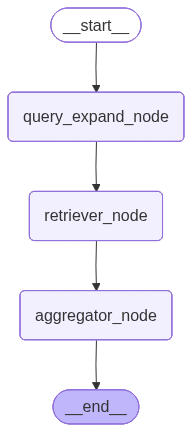

In [83]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [84]:
user_question = "3 popular restaurants in tucson and 2 best restaurants in New Orleans"
initial_state = {
    "initial_query": user_question,
}

In [85]:
result = graph.invoke(initial_state)

20:41:18 superlinked.framework.query.query_dag_evaluator INFO   evaluated query
20:41:18 superlinked.framework.dsl.executor.query.query_executor INFO   executed query
20:41:27 superlinked.framework.common.delayed_evaluator INFO   Processed sentence-transformers/all-MiniLM-L6-v2 embed
20:41:27 superlinked.framework.query.query_dag_evaluator INFO   evaluated query
20:41:27 superlinked.framework.dsl.executor.query.query_executor INFO   executed query


In [86]:
result

{'expanded_query': ['popular restaurants in Tucson',
  'best restaurants in New Orleans'],
 'retrieved_context': [{'retrived_restaurant_ids': ['ZHcfV3d7ZW8bmwgKCsz-RA',
    'tV46IhCfHbsx_af-pMupiw',
    'IKMAgK2m6WRIViVFB2vAFQ',
    'L1TzHZ8OXfVXTfyzidstzg',
    '4jkH3istYst8zxLxb-QVmg'],
   'retrived_restaurants_names': ['Pizza Luna',
    'Cafe Poca Cosa',
    'Miss Saigon',
    'Snooze An AM Eatery',
    'La Parrilla Suiza'],
   'retrived_restaurants_ratings': [4.5, 4.0, 4.0, 4.5, 3.0],
   'retrived_restaurants_reviews_count': [251, 1306, 702, 253, 340],
   'retrived_states': ['AZ', 'AZ', 'AZ', 'AZ', 'AZ'],
   'retrived_cities': ['Tucson', 'Tucson', 'Tucson', 'Tucson', 'Tucson'],
   'similarity_scores': [0.82659674,
    0.8255422,
    0.79330504,
    0.78300595,
    0.78156775]},
  {'retrived_restaurant_ids': ['a1u9Bxrq_fZxl2pgqQUcJA',
    'oBNrLz4EDhiscSlbOl8uAw',
    '-psZLTe6IJTQUB-bZF7Zyg',
    'XnQ84ylyAZwh-XfHGGNBbQ',
    'TUTQeLjq1UbkR5r8mOvMqw'],
   'retrived_restaurants_name

In [87]:
print(result["answer"])

Three popular restaurants in Tucson are:
1. Pizza Luna
   - Rating: 4.5
   - Reviews: 251
   - Location: Tucson, AZ
2. Cafe Poca Cosa
   - Rating: 4.0
   - Reviews: 1306
   - Location: Tucson, AZ
3. Miss Saigon
   - Rating: 4.0
   - Reviews: 702
   - Location: Tucson, AZ

Two best restaurants in New Orleans are:
1. The Governor
   - Rating: 4.5
   - Reviews: 330
   - Location: New Orleans, LA
2. Ruby Slipper - New Orleans
   - Rating: 4.5
   - Reviews: 5193
   - Location: New Orleans, LA


### Query expansion (Parrallel Execution)

In [124]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[dict], add] = []
    initial_query: str = ""
    answer: str = ""
    query: str = ""
    k: int = 10

### Query expansion /Rewriting Node

In [125]:
class QueryExpandResponse(BaseModel):
   expanded_query: List[str]

In [126]:
@traceable(
    name="query_expand_node",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def query_expand_node(state: State) -> dict:

   prompt_template =  """You are part of a shopping assistant that can answer questions about restaurants.

Instructions:
- You will be given a question and you need to expand it into a list of statements that can be used in contextual search to retrieve relevant restaurants.
- The statements should not overlap in context.
- The answer to the question should contain detailed information about the restaurant and returned with detailed specification in bullet points.

<Question>
{{ query }}
</Question>
"""

   template = Template(prompt_template)
   
   prompt = template.render(
      query=state.initial_query
   )

   client = instructor.from_openai(OpenAI())

   response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=QueryExpandResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
   )

   return {
      "expanded_query": response.expanded_query
   }

In [127]:
def query_expand_conditional_edges(state: State):

    send_messages = []

    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retrieve_node",
                {
                    "query": query,
                    "k": 10
                }
            )
        )

    return send_messages

### retriever node

In [134]:
@traceable(
    name="retriever_top_n",
    run_type="retriever",
    )
def retrieve_node(state: State) -> dict:
    qdrant_results = qdrant_app.query(
        query,
        natural_query=state["query"],
        limit=state["k"],
    )

    format_minute_columns_to_hhmm(sl.PandasConverter.to_pandas(qdrant_results))

    return {
        "retrieved_context": [{
            "retrived_restaurant_ids":[e.id for e in qdrant_results.entries],
            "retrived_restaurants_names":[e.fields.get("name") for e in qdrant_results.entries],
            "retrived_restaurants_ratings":[e.fields.get("stars") for e in qdrant_results.entries],
            "retrived_restaurants_reviews_count":[e.fields.get("review_count") for e in qdrant_results.entries],
            "retrived_states":[e.fields.get("state") for e in qdrant_results.entries],
            "retrived_cities":[e.fields.get("city") for e in qdrant_results.entries],
            "similarity_scores":[e.metadata.score for e in qdrant_results.entries],
        }],
    }


    

### Aggregator node

In [129]:
class AggregatorResponse(BaseModel):
    answer: str= Field(description="The answer to the question")

    
    

In [130]:
@traceable(
   name="aggregator_node",
   run_type="llm",
   metadata={"ls_provider":"openai", "ls_model_name":"gpt-4.1-mini"}
   )
def aggregator_node(state:State) -> dict:
   preprocessed_context = "\n".join(json.dumps(ctx) for ctx in state.retrieved_context)

   prompt_template =  """You are a shopping assistant that can answer questions about the restaurants in the context.

You will be given a question and a list of context.

Instructions:
- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

Context:
{{ preprocessed_context }}

Question:
{{ question }}
"""

   template = Template(prompt_template)
   
   prompt = template.render(
      preprocessed_context=preprocessed_context,
      question=state.initial_query
   )

   client = instructor.from_openai(OpenAI())

   response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=AggregatorResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
   )

   return {
      "answer": response.answer
   }

In [135]:
workflow = StateGraph(State)

workflow.add_node("query_expand_node", query_expand_node)
workflow.add_node("retrieve_node", retrieve_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_edge(START, "query_expand_node")
workflow.add_conditional_edges("query_expand_node", query_expand_conditional_edges)
workflow.add_edge("retrieve_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

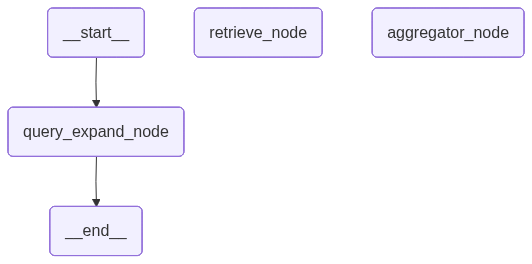

In [136]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [137]:
result = graph.invoke(initial_state)

21:36:51 superlinked.framework.query.query_dag_evaluator INFO   evaluated query
21:36:51 superlinked.framework.dsl.executor.query.query_executor INFO   executed query
21:36:56 superlinked.framework.query.query_dag_evaluator INFO   evaluated query
21:36:56 superlinked.framework.dsl.executor.query.query_executor INFO   executed query


In [138]:
result

{'expanded_query': ['popular restaurants in Tucson',
  'best restaurants in New Orleans'],
 'retrieved_context': [{'retrived_restaurant_ids': ['ZHcfV3d7ZW8bmwgKCsz-RA',
    'tV46IhCfHbsx_af-pMupiw',
    'IKMAgK2m6WRIViVFB2vAFQ',
    'L1TzHZ8OXfVXTfyzidstzg',
    '4jkH3istYst8zxLxb-QVmg',
    'cGHRiW3ObFO1eOMUTBBM_Q',
    'ltmenUcFgNv7fPOU2BiwKw',
    'XR6zkgsFiwnaH2FVkoUVAQ',
    'zL7wVx6Ihf1VEb9Wi7P0bw',
    'D44IBRDtEScaWELey5IfCA'],
   'retrived_restaurants_names': ['Pizza Luna',
    'Cafe Poca Cosa',
    'Miss Saigon',
    'Snooze An AM Eatery',
    'La Parrilla Suiza',
    'Taegukgi',
    'El Minuto Cafe',
    'American Eat Company',
    'Beaut Burger',
    "May's Counter Chicken And Waffles"],
   'retrived_restaurants_ratings': [4.5,
    4.0,
    4.0,
    4.5,
    3.0,
    4.0,
    3.5,
    4.0,
    4.0,
    3.5],
   'retrived_restaurants_reviews_count': [251,
    1306,
    702,
    253,
    340,
    156,
    224,
    235,
    179,
    408],
   'retrived_states': ['AZ',
    'AZ',

In [139]:
print(result["answer"])

Three popular restaurants in Tucson based on ratings and review counts are:
1. Cafe Poca Cosa
   - Rating: 4.0
   - Reviews: 1306
2. Miss Saigon
   - Rating: 4.0
   - Reviews: 702
3. Pizza Luna
   - Rating: 4.5
   - Reviews: 251

Two best restaurants in New Orleans based on ratings and review counts are:
1. Ruby Slipper - New Orleans
   - Rating: 4.5
   - Reviews: 5193
2. The Governor
   - Rating: 4.5
   - Reviews: 330
